In [644]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce
from sklearn.model_selection import train_test_split

df = pd.read_csv("ToyotaCorolla.csv")
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


Из следующего кода видно, что:
- У нас есть 1436 строк, ни одного пропуска
- Price, Color, Fuel_Type необходимо закодировать так как они хранятся как object

In [645]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


Закодируем Fuel_Type используя бинарную кодировку(OneHotEncoding)
- 1 - Diesel
- 0 - Petrol

In [646]:
df = pd.get_dummies(df, columns=['Fuel_Type'])
df['Fuel_Type_Diesel'].value_counts()

Fuel_Type_Diesel
False    1281
True      155
Name: count, dtype: int64

Перейдем к свойству Color. Есть 3 редко встречающиеся цвета. Сгруппируем их в Other

In [647]:
df['Color'].value_counts()

Color
Grey      301
Blue      283
Red       278
Green     220
Black     191
Silver    122
White      31
Violet      4
Yellow      3
Beige       3
Name: count, dtype: int64

In [648]:
low_frequency_colors = df['Color'].value_counts()[df['Color'].value_counts() < 10].index
df['Color'] = df['Color'].replace(low_frequency_colors, 'Other')
df['Color'].value_counts()

Color
Grey      301
Blue      283
Red       278
Green     220
Black     191
Silver    122
White      31
Other      10
Name: count, dtype: int64

In [649]:
df = pd.get_dummies(df, columns=['Color'])

Разделим датасет на train, test


In [650]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(["Price"], axis=1), df["Price"], test_size=0.2)

- Используем TargetEncoding, чтобы закодировать Model
- Добавим smoothing=10, чтобы избежать overfitting, для редких моделей

In [651]:
target_encoder = ce.TargetEncoder(cols=['Model'], smoothing=10)

X_train = target_encoder.fit_transform(X_train, y_train)
X_test = target_encoder.transform(X_test)

In [652]:
X_test.shape

(288, 47)

In [653]:
X_train.shape

(1148, 47)

In [654]:
corr_matrix = pd.concat([y_train, X_train], axis=1).corr()

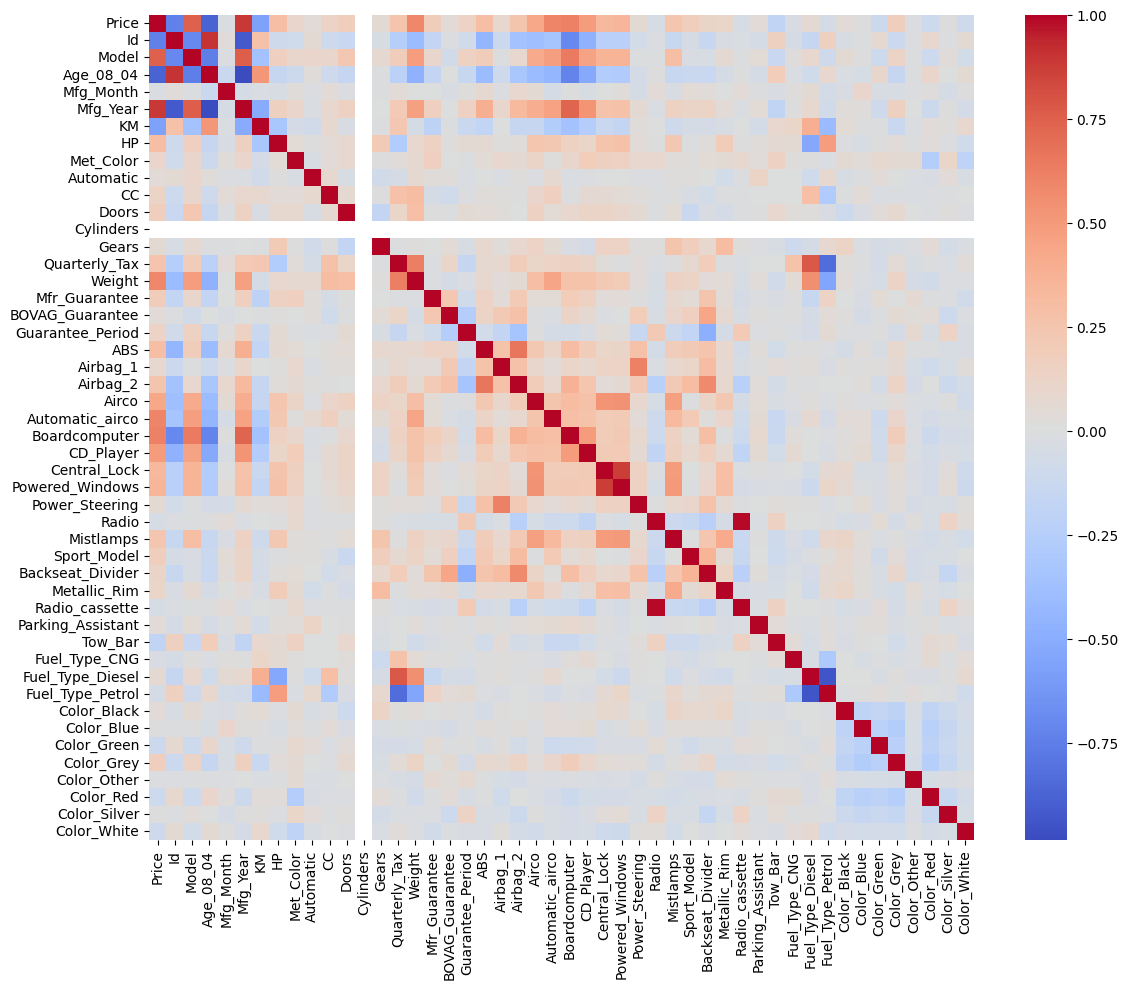

In [655]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.tight_layout()
plt.show()

Найдем самые коррелирующие признаки

In [656]:
features = corr_matrix['Price'].drop('Price')[corr_matrix['Price'].apply(lambda x: abs(x) > .35)]
features = features.index
features

Index(['Id', 'Model', 'Age_08_04', 'Mfg_Year', 'KM', 'Weight', 'Airco',
       'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Powered_Windows'],
      dtype='object')

In [657]:
X_train = X_train[features]
X_test = X_test[features]
X_train.head()

,Id,Model,Age_08_04,Mfg_Year,KM,Weight,Airco,Automatic_airco,Boardcomputer,CD_Player,Powered_Windows
40,41,11409.919250,22,2002,49059,1100,0,0,1,0,0
692,696,9448.379451,61,1999,97425,1075,1,0,0,0,1
975,980,8171.372236,65,1999,47014,1015,0,0,0,0,0
101,102,12388.662804,19,2003,19200,1100,1,0,1,0,1
966,970,8683.180902,62,1999,49258,1035,1,0,0,0,1


## Обучение

In [658]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [659]:
model_lr = LinearRegression().fit(X_train, y_train)
model_ridge = Ridge().fit(X_train, y_train)
model_lasso = Lasso().fit(X_train, y_train)

In [660]:
predicted = model_lasso.predict(X_test)

In [661]:
mse = mean_squared_error(y_test, predicted)
mae = mean_absolute_error(y_test, predicted)
r2 = r2_score(y_test, predicted)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

MSE: 1436320.30
MAE: 839.25
R2 Score: 0.8873


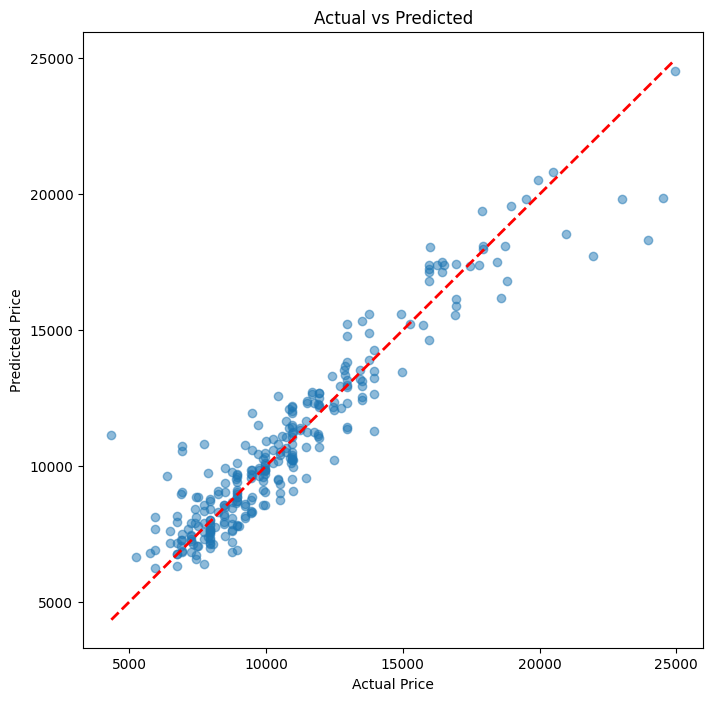

In [662]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predicted, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45-degree line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()